# 05. 정확도, 지연, 비용 비교 평가

## 배경

"Jev 를 쓰면 도구 선택이 더 정확해진다"는 주장은 측정하기 전에는 가설입니다. 이 노트북은 라벨이 붙은 질의 30건으로 세 가지 방식을 비교합니다.

| 방식 | 설명 |
|---|---|
| LLM 단독 | 도구 10개를 모두 바인딩하고 LLM 이 고르게 함 |
| Jev 단독 | `choice` 질문으로 고름 |
| 캐스케이드 | Jev 가 확신하면 Jev, 아니면 LLM |

측정 항목은 정확도, 평균 지연, 총 비용입니다.

## 읽는 법

30건은 작은 표본입니다. 한두 건 차이로 정확도가 3~7%p 움직이므로 순위를 단정하지 말고, 어떤 질의에서 틀렸는지를 같이 봐야 합니다. 이 평가셋과 도구 설명은 같은 사람이 썼고 정답을 "요청을 직접 처리하는 도구 하나"로 정의했습니다. 그래서 Jev 의 `choice` 질문에 유리한 설정입니다. LLM 이 환불 전에 주문 조회부터 하는 것은 실제 에이전트에서는 합리적인 행동인데 여기서는 오답으로 셉니다. 본인 서비스의 실제 질의로 평가셋을 바꿔 다시 돌리는 것이 이 노트북의 진짜 사용법입니다.

In [1]:
import sys
sys.path.insert(0, "..")  # 프로젝트 루트의 jev_agent 패키지를 불러오기 위함

from dotenv import load_dotenv
load_dotenv("../.env")

from jev_agent.jev import JevClient, choice, noul, score

jev = JevClient()

In [2]:
import pandas as pd
from jev_agent.evalset import EVAL_CASES
from jev_agent.middleware import NO_TOOL
from jev_agent.tools import TOOLS, tool_catalog

OPTIONS = {**tool_catalog(), NO_TOOL: "도구가 필요 없다. 인사나 잡담이다."}
QUESTION = {"tool": choice("사용자 요청을 처리하기 위해 실행해야 할 도구는 무엇인가?", OPTIONS)}

pd.DataFrame(EVAL_CASES, columns=["질의", "정답"]).head(10)

,질의,정답
0,A1001 지금 어디쯤 왔어요?,track_shipping
1,A1003 언제 도착하나요?,track_shipping
2,택배가 아직도 안 왔어요. 주문번호 A1001 이에요.,track_shipping
3,A1002 제가 뭘 샀었죠?,search_order
4,A1001 결제 금액이 얼마였는지 확인해 주세요.,search_order
5,주문 A1003 내역 좀 보여주세요.,search_order
6,A1003 아직 안 보냈으면 주문 취소해 주세요.,cancel_order
7,방금 결제한 A1003 잘못 샀어요. 없던 걸로 해주세요.,cancel_order
8,A1003 주문 철회하고 싶습니다.,cancel_order
9,A1002 받았는데 소리가 안 나요. 돈 돌려주세요.,request_refund


## 방식별 실행 함수

LLM 비용은 응답의 토큰 수에 OpenRouter 공개 가격표의 단가를 곱해 계산합니다.

In [3]:
import time, httpx
from jev_agent.agent import build_chat_model

llm = build_chat_model()
llm_with_tools = llm.bind_tools(TOOLS)

# Jev 와 같은 과제를 주기 위한 지시문. 이 지시가 없으면 LLM 은 주문 조회부터 하는 경우가 많다.
LLM_INSTRUCTION = (
    "당신은 쇼핑몰 고객지원 상담원입니다. 사용자 요청을 직접 처리하는 도구 하나를 바로 호출하세요. "
    "사전 조회용 도구를 먼저 부르지 마세요. 도구가 필요 없는 인사나 잡담이면 도구를 호출하지 마세요."
)

prices = {
    model["id"]: model["pricing"]
    for model in httpx.get("https://openrouter.ai/api/v1/models", timeout=30).json()["data"]
}
llm_price = prices[llm.model_name]

def llm_cost(message) -> float:
    usage = message.usage_metadata or {}
    return usage.get("input_tokens", 0) * float(llm_price["prompt"]) + usage.get("output_tokens", 0) * float(llm_price["completion"])

def run_llm(query: str) -> dict:
    started = time.perf_counter()
    message = llm_with_tools.invoke([("system", LLM_INSTRUCTION), ("user", query)])
    picked = message.tool_calls[0]["name"] if message.tool_calls else NO_TOOL
    return {"tool": picked, "latency_ms": (time.perf_counter() - started) * 1000, "cost": llm_cost(message)}

def run_jev(query: str) -> dict:
    result = jev.decide({"user_request": query}, QUESTION)
    answer = result["tool"]
    return {"tool": answer["choice"], "latency_ms": result.latency_ms, "cost": result.cost, "confidence": answer["confidence"]}

def run_cascade(query: str, min_confidence: float = 0.5) -> dict:
    first = run_jev(query)
    if first["confidence"] >= min_confidence:
        return {**first, "decided_by": "Jev"}
    second = run_llm(query)
    return {
        "tool": second["tool"],
        "latency_ms": first["latency_ms"] + second["latency_ms"],
        "cost": first["cost"] + second["cost"],
        "confidence": first["confidence"],
        "decided_by": "LLM",
    }

## 실행

LLM 호출이 포함되어 1~2분 걸립니다.

In [4]:
records = []
for query, expected in EVAL_CASES:
    for method, runner in [("LLM 단독", run_llm), ("Jev 단독", run_jev), ("캐스케이드", run_cascade)]:
        outcome = runner(query)
        records.append({"방식": method, "질의": query, "정답": expected, "is_correct": outcome["tool"] == expected, **outcome})

results = pd.DataFrame(records)
summary = results.groupby("방식").agg(
    정확도=("is_correct", "mean"),
    평균지연_ms=("latency_ms", "mean"),
    총비용_USD=("cost", "sum"),
).round({"정확도": 3, "평균지연_ms": 0, "총비용_USD": 6})
summary

,정확도,평균지연_ms,총비용_USD
방식,,,
Jev 단독,1.000,281.0,0.001002
LLM 단독,0.933,1037.0,0.014704
캐스케이드,0.967,324.0,0.001476


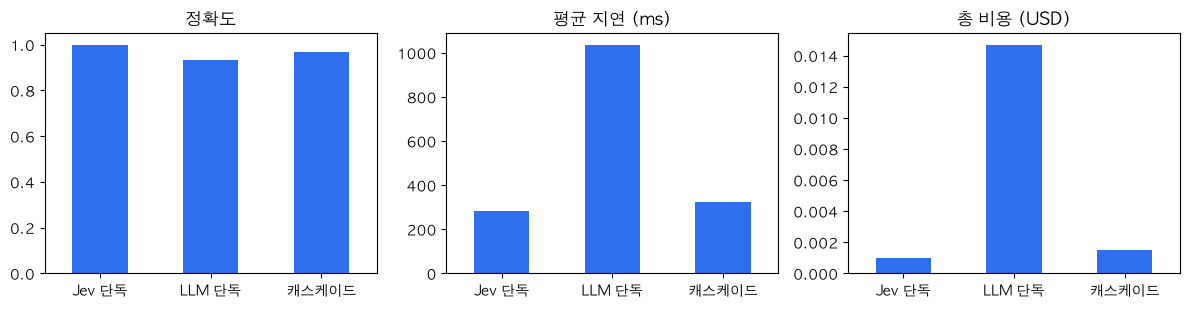

In [5]:
import matplotlib.pyplot as plt

from matplotlib import font_manager

installed = {font.name for font in font_manager.fontManager.ttflist}
korean_font = next((name for name in ["AppleGothic", "Malgun Gothic", "NanumGothic"] if name in installed), "sans-serif")
plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for axis, (column, title) in zip(axes, [("정확도", "정확도"), ("평균지연_ms", "평균 지연 (ms)"), ("총비용_USD", "총 비용 (USD)")]):
    summary[column].plot.bar(ax=axis, color="#2f6fed", rot=0)
    axis.set_title(title)
    axis.set_xlabel("")
plt.tight_layout()
plt.show()

## 어디서 틀렸나

정확도 숫자보다 틀린 질의 목록이 더 많은 것을 알려 줍니다. 도구 설명을 고치면 해결될 오류인지, 질의 자체가 애매한지 구분해 보세요.

In [6]:
results[~results["is_correct"]][["방식", "질의", "정답", "tool"]].sort_values("질의")

,방식,질의,정답,tool
63,LLM 단독,P20 지금 살 수 있나요? 품절인가요?,check_stock,search_products
23,캐스케이드,방금 결제한 A1003 잘못 샀어요. 없던 걸로 해주세요.,cancel_order,search_order
30,LLM 단독,이어폰 A1002 불량이라 환불 접수 부탁드립니다.,request_refund,escalate_to_human


## confidence 는 믿을 만한가

Jev 가 확신한다고 답한 판단이 실제로 더 자주 맞는지 확인합니다. confidence 구간별 정확도가 구간이 올라갈수록 높아지면 캐스케이드의 전제가 성립합니다. 모든 구간이 1.0 으로 나오면 이 평가셋이 Jev 에게 쉬웠다는 뜻일 뿐이고, probability 가 calibration 이 잘 됐는지는 이 데이터로 판단할 수 없습니다.

In [7]:
jev_only = results[results["방식"] == "Jev 단독"].copy()
jev_only["confidence 구간"] = pd.cut(jev_only["confidence"], bins=[0, 0.5, 0.8, 1.0], include_lowest=True)
jev_only.groupby("confidence 구간", observed=True).agg(건수=("is_correct", "size"), 정확도=("is_correct", "mean")).round(2)

,건수,정확도
confidence 구간,,
"(-0.001, 0.5]",1,1.0
"(0.5, 0.8]",4,1.0
"(0.8, 1.0]",25,1.0


## 기준값을 바꾸면

캐스케이드 기준값을 올리면 LLM 에게 넘어가는 비율이 늘어납니다. 앞에서 구한 결과를 재사용하므로 추가 호출 없이 계산됩니다.

In [8]:
jev_rows = results[results["방식"] == "Jev 단독"].set_index("질의")
llm_rows = results[results["방식"] == "LLM 단독"].set_index("질의")

sweep = []
for threshold in [0.0, 0.3, 0.5, 0.7, 0.9, 1.01]:
    use_jev = jev_rows["confidence"] >= threshold
    is_correct = jev_rows["is_correct"].where(use_jev, llm_rows["is_correct"])
    cost = jev_rows["cost"] + llm_rows["cost"].where(~use_jev, 0)
    latency = jev_rows["latency_ms"] + llm_rows["latency_ms"].where(~use_jev, 0)
    sweep.append({
        "기준값": threshold,
        "LLM 위임 비율": round(1 - use_jev.mean(), 2),
        "정확도": round(is_correct.mean(), 3),
        "평균지연_ms": round(latency.mean()),
        "총비용_USD": round(cost.sum(), 6),
    })
pd.DataFrame(sweep)

,기준값,LLM 위임 비율,정확도,평균지연_ms,총비용_USD
0,0.00,0.00,1.000,281,0.001002
1,0.30,0.00,1.000,281,0.001002
2,0.50,0.03,1.000,311,0.001476
3,0.70,0.10,1.000,383,0.002475
4,0.90,0.20,1.000,486,0.004032
5,1.01,1.00,0.933,1318,0.015706


## 정리

- 표의 숫자는 이 평가셋, 이 도구 설명, 이 LLM 에서의 결과입니다. 다른 조건에서는 달라집니다.
- **정확도 순위는 실행마다 바뀝니다.** 이 노트북을 같은 날 네 번 실행했을 때 Jev 단독은 100%, 100%, 96.7%, 100%, LLM 단독은 93.3%, 96.7%, 100%, 93.3% 였습니다. 30건에서 한 건이 3.3%p 이므로 두 방식의 정확도 차이는 이 평가셋으로는 가릴 수 없습니다.
- **지연과 비용 차이는 매번 같았습니다.** Jev 는 약 290ms, LLM 은 약 1,100ms 였고, 30건 비용은 약 14배 차이였습니다. 이 평가에서 분명하게 말할 수 있는 것은 이쪽입니다.
- 흔들린 질의는 주로 "방금 결제한 A1003 잘못 샀어요. 없던 걸로 해주세요."였습니다. 취소라는 말이 없어서 Jev confidence 가 0.5 이하로 나오고, 어떤 실행에서는 Jev 가, 어떤 실행에서는 넘겨받은 LLM 이 주문 조회로 잘못 골랐습니다. 캐스케이드가 항상 정답을 보장하지는 않습니다. confidence 가 낮다는 신호는 "이 건은 따로 봐야 한다"는 뜻이지 "LLM 이면 맞힌다"는 뜻이 아닙니다.
- 기준값 0 은 Jev 단독, 1.01 은 LLM 단독(Jev 호출 비용은 추가됨)과 같습니다. 그 사이에서 정확도와 비용이 만나는 지점을 찾습니다.
- 정확도가 낮게 나왔다면 모델보다 먼저 도구 설명을 고쳐 보세요. 도구 설명이 Jev 의 option 설명이기도 합니다.